In [ ]:
# @author July 2025.06.11
# Generate a sinusoidal velocity field

import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal, osr
import math
import matplotlib
import sys

# Configure matplotlib to support proper rendering (no special font needed now)
matplotlib.rcParams['axes.unicode_minus'] = False

# Open reference TIFF file to obtain geospatial information
ref_ds = gdal.Open(r"PATH\1.Simulated image\extentL9.tif")
if ref_ds is None:
    raise FileNotFoundError("Unable to open the reference TIFF file. Please check the path.")

# Get actual dimensions from the reference file
cols = ref_ds.RasterXSize
rows = ref_ds.RasterYSize
geotransform = ref_ds.GetGeoTransform()
projection = ref_ds.GetProjection()

print(f"Reference file size: {cols} columns x {rows} rows")
print(f"Geotransform parameters: {geotransform}")
print(f"Projection information: {projection[:50]}...")  # Print partial projection info

# Create grid coordinates based on actual dimensions
i_coords = np.arange(rows)
j_coords = np.arange(cols)
i_grid, j_grid = np.meshgrid(i_coords, j_coords, indexing='ij')

pi = 3.14
angle_deg = 45
theta = np.deg2rad(angle_deg)

# Define velocity field: vv = 0.1*i + 0.1*j + sinusoidal components
# Set periodicity
Ti = 500  # period in i-direction (pixels)
Tj = 500 # period in j-direction (pixels)

# Compute velocity magnitude
vv = 0.1 * i_grid + 0.1 * j_grid + \
     3 * np.sin(2 * np.pi * i_grid / Ti) + \
     3 * np.sin(2 * np.pi * j_grid / Tj)

# Compute eastward and northward components
# Eastward component: ux = vv * sin(theta)
theta = np.deg2rad(angle_deg)  # convert to radians
ux = vv * np.sin(theta)  # eastward component
uy = vv * np.cos(theta)  # northward component

Reference file size: 1171 columns x 709 rows
Geotransform parameters: (718854.2985965945, 15.0, 0.0, 3514673.532497386, 0.0, -15.0)
Projection information: PROJCS["WGS_1984_UTM_Zone_46N",GEOGCS["WGS 84",DAT...


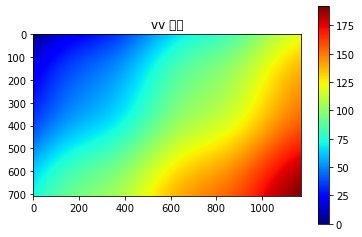

In [5]:
plt.imshow(vv, cmap='jet')
plt.colorbar()
plt.title('vv 曲面')
plt.show()

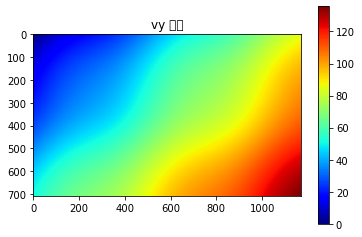

In [6]:
plt.imshow(ux, cmap='jet')
plt.colorbar()
plt.title('vy 曲面')
plt.show()

In [ ]:
# Save data as GeoTIFF with geospatial information
def save_geotiff(data, filename, rows, cols, geotransform, projection):
    """Save array data as a GeoTIFF with georeferencing"""
    driver = gdal.GetDriverByName('GTiff')
    out_ds = driver.Create(filename, cols, rows, 1, gdal.GDT_Float32)
    if out_ds is None:
        raise RuntimeError(f"Failed to create file: {filename}")
    out_ds.SetGeoTransform(geotransform)
    out_ds.SetProjection(projection)
    out_band = out_ds.GetRasterBand(1)
    out_band.WriteArray(data)
    out_band.FlushCache()
    out_ds = None

# Output filenames
save_geotiff(vv, r'PATH\1.Simulated image\T500_vv_sin.tif', rows, cols, geotransform, projection)
save_geotiff(ux, r'PATH\1.Simulated image\T500_ux_sin.tif', rows, cols, geotransform, projection)
save_geotiff(uy, r'PATH\1.Simulated image\T500_uy_sin.tif', rows, cols, geotransform, projection)

print("GeoTIFF files have been saved: vv.tif, ux.tif, uy.tif")

GeoTIFF files have been saved: vv.tif, ux.tif, uy.tif


In [ ]:
# ======================== Merge bands and compute velocity magnitude (vv) ========================

import matplotlib.pyplot as plt
import numpy as np
import os

plt.rcParams.update({'font.size': 20})

from osgeo import gdal
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.plot import show


def extract_by_mask(shp_path, raster_path, output_path):
    # Check if files exist
    if not os.path.exists(shp_path):
        print(f"Shapefile not found: {shp_path}")
        return
    if not os.path.exists(raster_path):
        print(f"Raster file not found: {raster_path}")
        return

    # Read vector file
    shp = gpd.read_file(shp_path)

    # Extract geometries (merge all features into one geometry set)
    geometries = shp.geometry.values

    # Open raster file
    with rasterio.open(raster_path) as src:
        # Perform clipping operation
        out_image, out_transform = mask(src, geometries, crop=True, nodata=src.nodata)

        # Update metadata
        out_meta = src.meta.copy()
        out_meta.update({
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
            "nodata": src.nodata,
            "count": out_image.shape[0]
        })

        # Write output file
        with rasterio.open(output_path, "w", **out_meta) as dest:
            dest.write(out_image)


def print_geoinfo(dataset, label):
    print(f"{label} - Projection: {dataset.GetProjection()}")
    print(f"{label} - GeoTransform: {dataset.GetGeoTransform()}")


def process_band(dataset, output_image_path):
    if dataset.RasterCount < 2:
        print("Error: Less than 2 bands in input image.")
        return

    # Read band 1 and band 2 data
    band1 = dataset.GetRasterBand(1)
    band1_data = band1.ReadAsArray().astype(np.float32)

    band2 = dataset.GetRasterBand(2)
    band2_data = band2.ReadAsArray().astype(np.float32)

    # Compute velocity magnitude (vv)
    band_vv = np.sqrt(band1_data ** 2 + band2_data ** 2)

    # Create output image
    driver = gdal.GetDriverByName('GTiff')
    output_dataset = driver.Create(
        output_image_path,
        dataset.RasterXSize,
        dataset.RasterYSize,
        1,
        gdal.GDT_Float32
    )

    if not output_dataset:
        print("Failed to create output image.")
        return

    # Set geotransform and projection
    output_dataset.SetGeoTransform(dataset.GetGeoTransform())
    output_dataset.SetProjection(dataset.GetProjection())

    # Write computed result
    output_band = output_dataset.GetRasterBand(1)
    output_band.WriteArray(band_vv)
    output_band.FlushCache()
    output_dataset.FlushCache()
    output_dataset = None

    # Verify output file
    output_dataset = gdal.Open(output_image_path)
    if not output_dataset:
        print("Failed to open output image.")
        return

    print("\nOutput Image Information:")
    print_geoinfo(output_dataset, "Output Image")
    output_dataset = None


if __name__ == "__main__":
    input_image_path = r'path\images_glacier_velocity.TIF'
    if not os.path.exists(input_image_path):
        print(f"Input image not found: {input_image_path}")
    else:
        dataset = gdal.Open(input_image_path)
        if not dataset:
            print("Failed to open input image.")
        else:
            print("Input Image Information:")
            print_geoinfo(dataset, "Input Image")

            # Process the first two bands and output vv
            vv_output_path = r'path\images_glacier_velocity_EW+NS.tif'
            process_band(dataset, vv_output_path)
            dataset = None

Input Image Information:
Input Image - Projection: PROJCS["UTM_Zone_46N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",93],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["Meter",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Input Image - GeoTransform: (718854.299, 15.0, -0.0, 3514673.532, -0.0, -15.0)

Output Image Information:
Output Image - Projection: PROJCS["WGS 84 / UTM zone 46N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",